In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 11

2026-04-01 18:38:34.369698: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775068714.556755      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775068714.607899      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775068715.038816      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775068715.038856      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775068715.038859      55 computation_placer.cc:177] computation placer alr

In [2]:
import os
import shutil

source_dir = "/kaggle/input/datasets/cookiefinder/tomato-disease-multiple-sources/train"   
target_dir = "/kaggle/working/tomato_dataset"

# Allowed image extensions
valid_ext = (".jpg", ".jpeg", ".png")

os.makedirs(target_dir, exist_ok=True)

for class_name in os.listdir(source_dir):
    class_src = os.path.join(source_dir, class_name)
    class_dst = os.path.join(target_dir, class_name)

    if os.path.isdir(class_src):
        os.makedirs(class_dst, exist_ok=True)

        for file in os.listdir(class_src):
            if file.lower().endswith(valid_ext):  
                src_file = os.path.join(class_src, file)
                dst_file = os.path.join(class_dst, file)
                shutil.copy2(src_file, dst_file)

print("✅ Clean dataset copied (only images)")

✅ Clean dataset copied (only images)


In [19]:
import tensorflow as tf

data_dir = "/kaggle/working/tomato_dataset"

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)
# IMPORTANT (prevents crash even if 1 bad file remains)
train_ds = train_ds.apply(tf.data.experimental.ignore_errors())
val_ds = val_ds.apply(tf.data.experimental.ignore_errors())
test_ds = test_ds.apply(tf.data.experimental.ignore_errors())

Found 25851 files belonging to 11 classes.
Using 20681 files for training.
Found 25851 files belonging to 11 classes.
Using 5170 files for validation.
Found 25851 files belonging to 11 classes.
Using 5170 files for validation.


In [14]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

In [4]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
import tensorflow as tf

IMG_SIZE = 224
BATCH_SIZE = 32

full_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/kaggle/working/tomato_dataset",   # your dataset folder
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=123
)

Found 25851 files belonging to 11 classes.


In [6]:
dataset_size = len(full_ds)
print("Total batches:", dataset_size)

train_size = int(0.7 * dataset_size)
val_size = int(0.2 * dataset_size)

train_ds = full_ds.take(train_size)
val_ds = full_ds.skip(train_size).take(val_size)
test_ds = full_ds.skip(train_size + val_size)

Total batches: 808


In [7]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [8]:
inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)

x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model = models.Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,428,491 (9.26 MB)

 Trainable params: 167,947 (656.04 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2
    )
]

In [15]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50
    646/Unknown 36s 56ms/step - accuracy: 0.4617 - loss: 1.6682

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


646/646 ━━━━━━━━━━━━━━━━━━━━ 46s 71ms/step - accuracy: 0.4618 - loss: 1.6680 - val_accuracy: 0.6882 - val_loss: 0.9300 - learning_rate: 1.0000e-04
Epoch 2/50
646/646 ━━━━━━━━━━━━━━━━━━━━ 46s 71ms/step - accuracy: 0.6016 - loss: 1.2082 - val_accuracy: 0.7313 - val_loss: 0.7912 - learning_rate: 1.0000e-04
Epoch 3/50
646/646 ━━━━━━━━━━━━━━━━━━━━ 45s 70ms/step - accuracy: 0.6497 - loss: 1.0412 - val_accuracy: 0.7625 - val_loss: 0.7082 - learning_rate: 1.0000e-04
Epoch 4/50
646/646 ━━━━━━━━━━━━━━━━━━━━ 46s 71ms/step - accuracy: 0.6812 - loss: 0.9360 - val_accuracy: 0.7691 - val_loss: 0.6731 - learning_rate: 1.0000e-04
Epoch 5/50
646/646 ━━━━━━━━━━━━━━━━━━━━ 46s 71ms/step - accuracy: 0.7024 - loss: 0.8609 - val_accuracy: 0.7787 - val_loss: 0.6328 - learning_rate: 1.0000e-04
Epoch 6/50
646/646 ━━━━━━━━━━━━━━━━━━━━ 45s 70ms/step - accuracy: 0.7147 - loss: 0.8261 - val_accuracy: 0.7901 - val_loss: 0.6035 - learning_rate: 1.0000e-04
Epoch 7/50
646/646 ━━━━━━━━━━━━━━━━━━━━ 45s 70ms/step - accurac

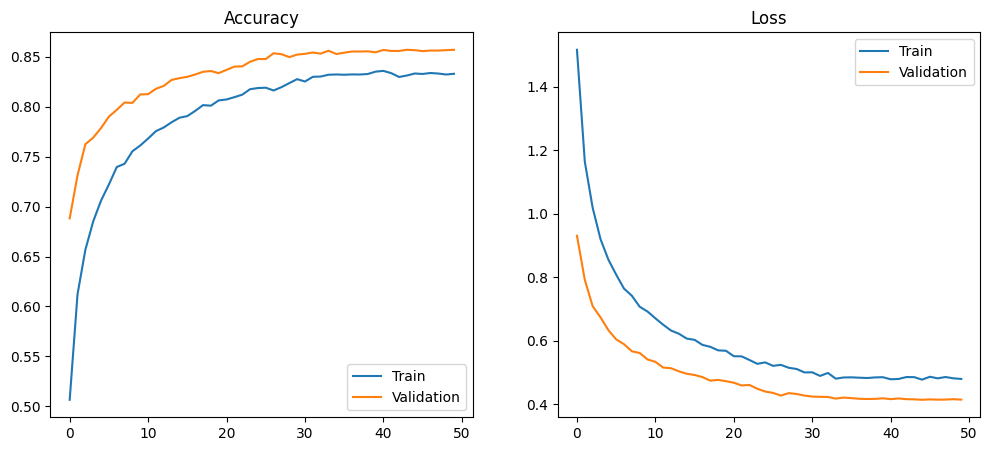

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()

plt.show()

In [20]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)

162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.8649 - loss: 0.3986
Test Accuracy: 0.8566731214523315


In [21]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50
646/646 ━━━━━━━━━━━━━━━━━━━━ 69s 92ms/step - accuracy: 0.7113 - loss: 0.8618 - val_accuracy: 0.7985 - val_loss: 0.6548 - learning_rate: 1.0000e-05
Epoch 2/50
646/646 ━━━━━━━━━━━━━━━━━━━━ 57s 89ms/step - accuracy: 0.7782 - loss: 0.6543 - val_accuracy: 0.8319 - val_loss: 0.5078 - learning_rate: 1.0000e-05
Epoch 3/50
646/646 ━━━━━━━━━━━━━━━━━━━━ 57s 89ms/step - accuracy: 0.7982 - loss: 0.5857 - val_accuracy: 0.8499 - val_loss: 0.4455 - learning_rate: 1.0000e-05
Epoch 4/50
646/646 ━━━━━━━━━━━━━━━━━━━━ 57s 89ms/step - accuracy: 0.8119 - loss: 0.5398 - val_accuracy: 0.8578 - val_loss: 0.4230 - learning_rate: 1.0000e-05
Epoch 5/50
646/646 ━━━━━━━━━━━━━━━━━━━━ 57s 89ms/step - accuracy: 0.8302 - loss: 0.4905 - val_accuracy: 0.8629 - val_loss: 0.3972 - learning_rate: 1.0000e-05
Epoch 6/50
646/646 ━━━━━━━━━━━━━━━━━━━━ 57s 89ms/step - accuracy: 0.8432 - loss: 0.4514 - val_accuracy: 0.8708 - val_loss: 0.3721 - learning_rate: 1.0000e-05
Epoch 7/50
646/646 ━━━━━━━━━━━━━━━━━━━━ 57s 89ms/ste

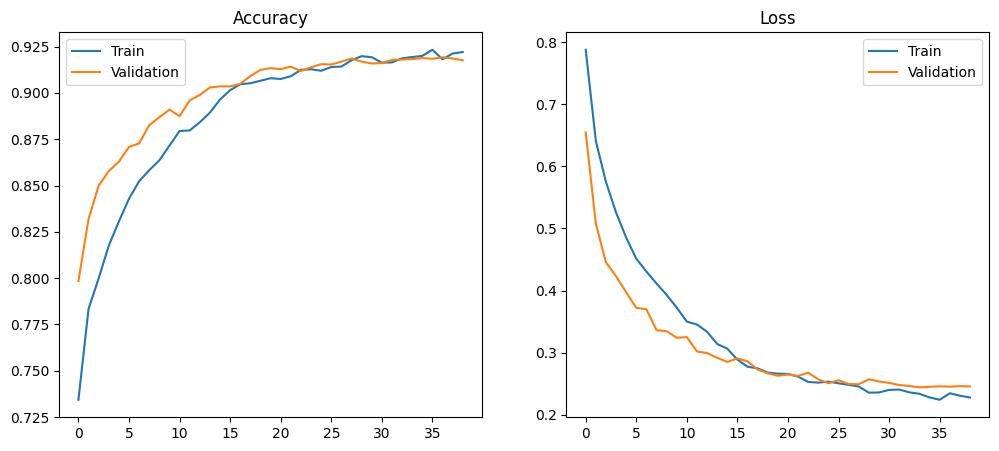

In [22]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_fine.history['accuracy'], label='Train')
plt.plot(history_fine.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history_fine.history['loss'], label='Train')
plt.plot(history_fine.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()

plt.show()

In [23]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)

162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.9172 - loss: 0.2420
Test Accuracy: 0.918181836605072


In [24]:
import os

base_path = "/kaggle/working/models"

os.makedirs(base_path, exist_ok=True)

existing = [int(i) for i in os.listdir(base_path) if i.isdigit()]
model_version = max(existing + [0]) + 1

model.save(f"{base_path}/{model_version}.keras")

print(f"Model saved as version {model_version}")

Model saved as version 1
